**Setup the energy function for the Eight-rook problem and solve the same using Hopfield network.  Give reasons for choosing specific weights for the network.**

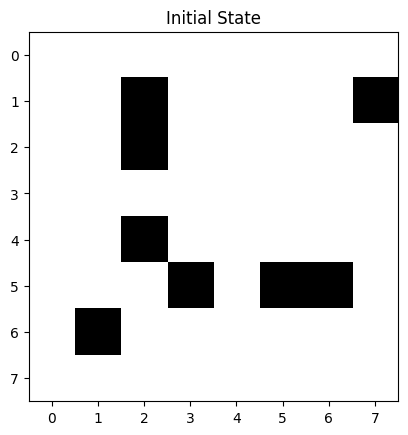

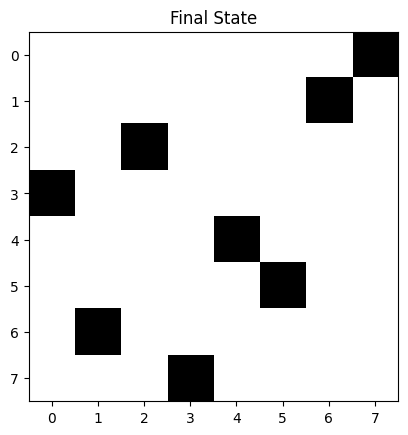

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize the board
def initialize_board(state):
    positions = set()
    while len(positions) < 8:
        new_position = np.random.randint(0, 64)
        positions.add(new_position)
    for pos in positions:
        row, col = divmod(pos, 8)
        state[row][col] = 1

# Calculate the energy difference for a potential flip
def calculate_energy_change(board, row1, col1, row2, col2):
    initial_row1_sum = sum(board[row1])
    initial_col1_sum = sum(board[:, col1])
    initial_row2_sum = sum(board[row2])
    initial_col2_sum = sum(board[:, col2])

    board[row1][col1], board[row2][col2] = 0, 1

    new_row1_sum = sum(board[row1])
    new_col1_sum = sum(board[:, col1])
    new_row2_sum = sum(board[row2])
    new_col2_sum = sum(board[:, col2])

    board[row1][col1], board[row2][col2] = 1, 0

    delta_energy = (
        (new_row1_sum - 1) ** 2 - (initial_row1_sum - 1) ** 2 +
        (new_col1_sum - 1) ** 2 - (initial_col1_sum - 1) ** 2 +
        (new_row2_sum - 1) ** 2 - (initial_row2_sum - 1) ** 2 +
        (new_col2_sum - 1) ** 2 - (initial_col2_sum - 1) ** 2
    )
    return delta_energy

# Attempt to flip and minimize energy
def attempt_flip(current_energy, board):
    while True:
        pos1 = np.random.randint(0, 64)
        pos2 = np.random.randint(0, 64)
        row1, col1 = divmod(pos1, 8)
        row2, col2 = divmod(pos2, 8)

        if board[row1][col1] == 1 and board[row2][col2] == 0:
            delta_energy = calculate_energy_change(board, row1, col1, row2, col2)
            if delta_energy < 0:
                board[row1][col1], board[row2][col2] = 0, 1
                current_energy += delta_energy
                return current_energy

# Initialize and optimize the board
board = np.zeros((8, 8))
initialize_board(board)

# Display the initial state
plt.imshow(board, cmap='binary', interpolation='nearest')
plt.title("Initial State")
plt.show()

# Reduce energy over iterations
current_energy = calculate_energy(board)
num_iterations = 1000
for iteration in range(num_iterations):
    current_energy = attempt_flip(current_energy, board)
    if current_energy == 0:
        break

# Display the final state
plt.imshow(board, cmap='binary', interpolation='nearest')
plt.title("Final State")
plt.show()


Solve a TSP (traveling salesman problem) of 10 cities with a Hopfield network.  


Optimal Tour Sequence:
Start at City D
Move to City C
Move to City H
Move to City E
Move to City I
Move to City F
Move to City B
Move to City A
Move to City J
Move to City G
Return to City D
Minimum Tour Cost: 155.84


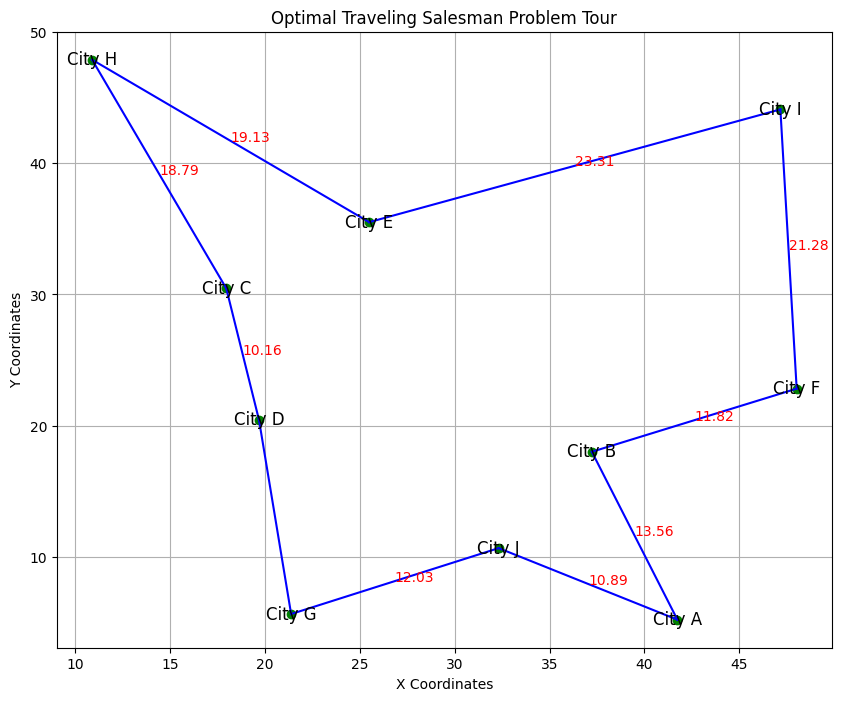

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define cities with unique identifiers
city_labels = ['City A', 'City B', 'City C', 'City D', 'City E', 'City F', 'City G', 'City H', 'City I', 'City J']

# Generate random coordinates for cities
np.random.seed(44)  # Ensures reproducibility
city_coordinates = {label: np.random.rand(2) * 50 for label in city_labels}

# Function to compute Euclidean distance between cities
def compute_city_distances(city_labels):
    num_cities = len(city_labels)
    dist_matrix = np.zeros((num_cities, num_cities))
    for idx1, city1 in enumerate(city_labels):
        for idx2, city2 in enumerate(city_labels):
            if idx1 != idx2:
                dist_matrix[idx1, idx2] = np.linalg.norm(city_coordinates[city1] - city_coordinates[city2])
    return dist_matrix

class TSPSolver:
    def __init__(self, city_labels, dist_matrix):
        self.city_labels = city_labels
        self.num_cities = len(city_labels)
        self.distances = dist_matrix
        self.penalties = np.zeros((self.num_cities, self.num_cities))
        self.set_up_penalties()

    def set_up_penalties(self):
        for i in range(self.num_cities):
            for j in range(self.num_cities):
                if i != j:
                    self.penalties[i, j] = -self.distances[i, j]

    def calculate_total_cost(self, tour):
        cost = 0
        for i in range(self.num_cities - 1):
            cost += self.distances[tour[i], tour[i + 1]]
        cost += self.distances[tour[-1], tour[0]]  # Return to the starting city
        return cost

    def find_optimal_tour(self, max_iters=100000):
        min_cost = float('inf')
        best_tour = None
        current_tour = np.random.permutation(self.num_cities)

        for _ in range(max_iters):
            i, j = np.random.choice(self.num_cities, 2, replace=False)
            cost_diff = 2 * (
                self.penalties[i].dot(current_tour) * current_tour[i]
                + self.penalties[j].dot(current_tour) * current_tour[j]
            )
            if cost_diff < 0:
                current_tour[i], current_tour[j] = current_tour[j], current_tour[i]
                tour_cost = self.calculate_total_cost(current_tour)
                if tour_cost < min_cost:
                    min_cost = tour_cost
                    best_tour = current_tour.copy()
        return best_tour, min_cost

# Compute distances between cities
dist_matrix = compute_city_distances(city_labels)

# Initialize the TSP Solver
tsp_solver = TSPSolver(city_labels, dist_matrix)

# Solve the TSP problem
best_tour, best_cost = tsp_solver.find_optimal_tour()

# Output the optimal route
print("Optimal Tour Sequence:")
for idx, city_idx in enumerate(best_tour):
    city_name = city_labels[city_idx]
    if idx == 0:
        print(f"Start at {city_name}")
    else:
        print(f"Move to {city_name}")
print(f"Return to {city_labels[int(best_tour[0])]}")

print(f"Minimum Tour Cost: {best_cost:.2f}")

# Visualize the cities and the optimal tour
plt.figure(figsize=(10, 8))
for city in city_labels:
    plt.scatter(city_coordinates[city][0], city_coordinates[city][1], color='green')
    plt.text(city_coordinates[city][0], city_coordinates[city][1], city, ha='center', va='center', fontsize=12)

# Plot the optimal path
for i in range(len(best_tour) - 1):
    city1 = city_labels[int(best_tour[i])]
    city2 = city_labels[int(best_tour[i + 1])]
    plt.plot(
        [city_coordinates[city1][0], city_coordinates[city2][0]],
        [city_coordinates[city1][1], city_coordinates[city2][1]],
        color='blue'
    )
plt.plot(
    [city_coordinates[city_labels[int(best_tour[-1])]][0], city_coordinates[city_labels[int(best_tour[0])]][0]],
    [city_coordinates[city_labels[int(best_tour[-1])]][1], city_coordinates[city_labels[int(best_tour[0])]][1]],
    color='blue'
)

# Annotate distance on the plot
for i in range(len(best_tour) - 1):
    city1 = city_labels[int(best_tour[i])]
    city2 = city_labels[int(best_tour[i + 1])]
    mid_x = (city_coordinates[city1][0] + city_coordinates[city2][0]) / 2
    mid_y = (city_coordinates[city1][1] + city_coordinates[city2][1]) / 2
    plt.text(mid_x, mid_y, f"{dist_matrix[int(best_tour[i]), int(best_tour[i + 1])]:.2f}", color='red')

# Display plot
plt.title("Optimal Traveling Salesman Problem Tour")
plt.xlabel("X Coordinates")
plt.ylabel("Y Coordinates")
plt.grid(True)
plt.show()
